In [1]:
!pip install xarray

In [2]:
#%matplotlib inline 
# this line is required for the plots to appear in the Jupyter cells, rather than launching the matplotlib GUI
%matplotlib notebook
#this allows interactive view but you need to be in classic rather than CoCalc Jupyter notebook for this to work

%matplotlib inline

import matplotlib

import numpy as np

import matplotlib.pyplot as plt


# Let printing work the same in Python 2 and 3
from __future__ import division,print_function

# notice two underscores _ either side of future

import xarray as xr
import netCDF4 as nc




In [ ]:
# loads in NetCDF data 
data = xr.open_dataset(r"\Users\pmalesza\AppData\Local\Temp\Rar$DRa13096.43816\students_data\SWOT_L2_HR_PIXC_001_475_244R_20230807T044016_20230807T044027_PGD0_01.nc")

In [ ]:
# inspecting the groups

from netCDF4 import Dataset

ds = Dataset(r"/Users/pmalesza/AppData/Local/Temp/Rar$DRa13096.43816/students_data/SWOT_L2_HR_PIXC_001_475_244R_20230807T044016_20230807T044027_PGD0_01.nc")

print(ds.groups.keys())

dict_keys(['pixel_cloud', 'tvp', 'noise'])


In [ ]:
# produces long list of variables such as latitude, longitude, attributes etc.

import xarray as xr

data = xr.open_dataset(
    r"/Users/pmalesza/AppData/Local/Temp/Rar$DRa13096.43816/students_data/SWOT_L2_HR_PIXC_001_475_244R_20230807T044016_20230807T044027_PGD0_01.nc",
    group="pixel_cloud"
)

print(data)
print(data.data_vars)

<xarray.Dataset> Size: 2GB
Dimensions:                                (points: 7344105, complex_depth: 2,
                                            num_pixc_lines: 3265)
Coordinates:
    latitude                               (points) float64 59MB ...
    longitude                              (points) float64 59MB ...
Dimensions without coordinates: points, complex_depth, num_pixc_lines
Data variables: (12/62)
    azimuth_index                          (points) float64 59MB ...
    range_index                            (points) float64 59MB ...
    interferogram                          (points, complex_depth) float32 59MB ...
    power_plus_y                           (points) float32 29MB ...
    power_minus_y                          (points) float32 29MB ...
    coherent_power                         (points) float32 29MB ...
    ...                                     ...
    pixc_line_qual                         (num_pixc_lines) float64 26kB ...
    pixc_line_to_tvp         

In [ ]:
# prints full list of data variables in file
print(list(data.data_vars))

['azimuth_index', 'range_index', 'interferogram', 'power_plus_y', 'power_minus_y', 'coherent_power', 'x_factor_plus_y', 'x_factor_minus_y', 'water_frac', 'water_frac_uncert', 'classification', 'false_detection_rate', 'missed_detection_rate', 'prior_water_prob', 'prior_water_change', 'bright_land_flag', 'layover_impact', 'eff_num_rare_looks', 'height', 'cross_track', 'pixel_area', 'inc', 'phase_noise_std', 'dlatitude_dphase', 'dlongitude_dphase', 'dheight_dphase', 'dheight_droll', 'dheight_dbaseline', 'dheight_drange', 'darea_dheight', 'illumination_time', 'illumination_time_tai', 'eff_num_medium_looks', 'sig0', 'sig0_uncert', 'phase_unwrapping_region', 'ambiguity_cost1', 'ambiguity_cost2', 'instrument_range_cor', 'instrument_phase_cor', 'instrument_baseline_cor', 'sig0_cor_atmos_model', 'height_cor_xover', 'model_dry_tropo_cor', 'model_wet_tropo_cor', 'iono_cor_gim_ka', 'geoid', 'solid_earth_tide', 'load_tide_fes', 'load_tide_got', 'pole_tide', 'ancillary_surface_classification_flag', 

In [ ]:
# picked one data variable, 'height', and printed all information about it 
print(data["height"])

<xarray.DataArray 'height' (points: 7344105)> Size: 29MB
[7344105 values with dtype=float32]
Coordinates:
    latitude   (points) float64 59MB ...
    longitude  (points) float64 59MB ...
Dimensions without coordinates: points
Attributes:
    long_name:     height above reference ellipsoid
    units:         m
    quality_flag:  geolocation_qual
    valid_min:     -1500.0
    valid_max:     15000.0
    comment:       Height of the pixel above the reference ellipsoid.


In [ ]:
# checking whether 'height' contains real numbers 

print(np.nanmin(data.height.values))
print(np.nanmax(data.height.values))

0.4896131
816.2509


In [ ]:
# checking for missing values

print(np.isnan(data.height.values).sum())
print(np.isnan(data.latitude.values).sum())
print(np.isnan(data.longitude.values).sum())

0
0
0


In [11]:
print(matplotlib.get_backend())

inline


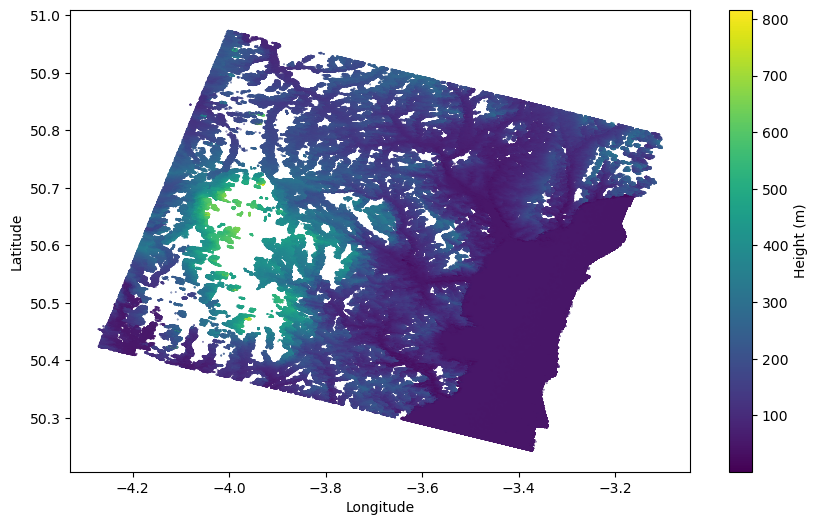

In [ ]:
# plot of 'height' 

plt.figure(figsize=(10,6))

plt.scatter(
    data.longitude.values,
    data.latitude.values,
    c=data.height.values,
    s=0.1,
    cmap="viridis"
)

plt.colorbar(label="Height (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
# prints minimum and maximum longitude and latitude

print("Longitude:")
print(data.longitude.min().item(), data.longitude.max().item())

print("Latitude:")
print(data.latitude.min().item(), data.latitude.max().item())

Longitude:
-4.270776177155142 -3.102776377171949
Latitude:
50.243257454393365 50.97287022780132


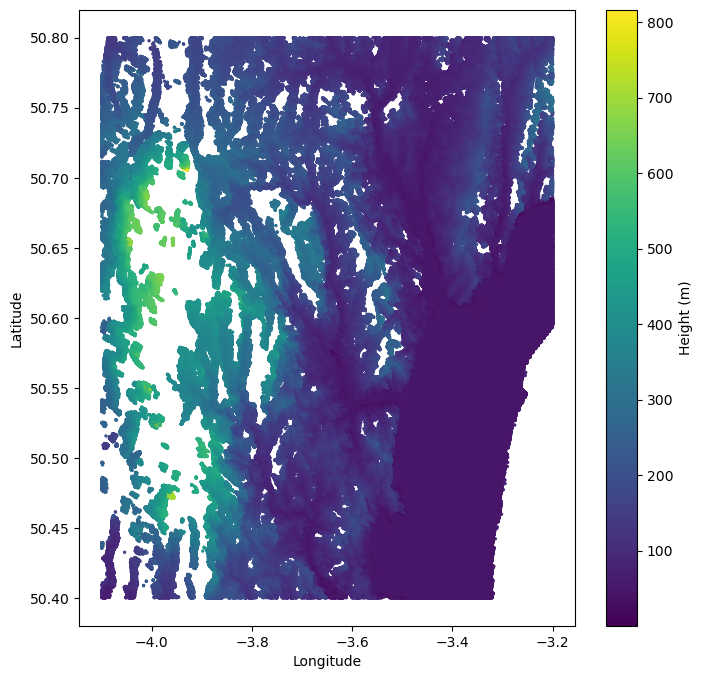

In [41]:
# subsetting 'height' data

lon_min = -4.1
lon_max = -3.2
lat_min = 50.4
lat_max = 50.8

mask = (
    (data.longitude >= lon_min) &
    (data.longitude <= lon_max) &
    (data.latitude >= lat_min) &
    (data.latitude <= lat_max)
)

plt.figure(figsize=(8,8))
plt.scatter(
    data.longitude.values[mask],
    data.latitude.values[mask],
    c=data.height.values[mask],
    s=2,
    cmap="viridis"
)

plt.colorbar(label="Height (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

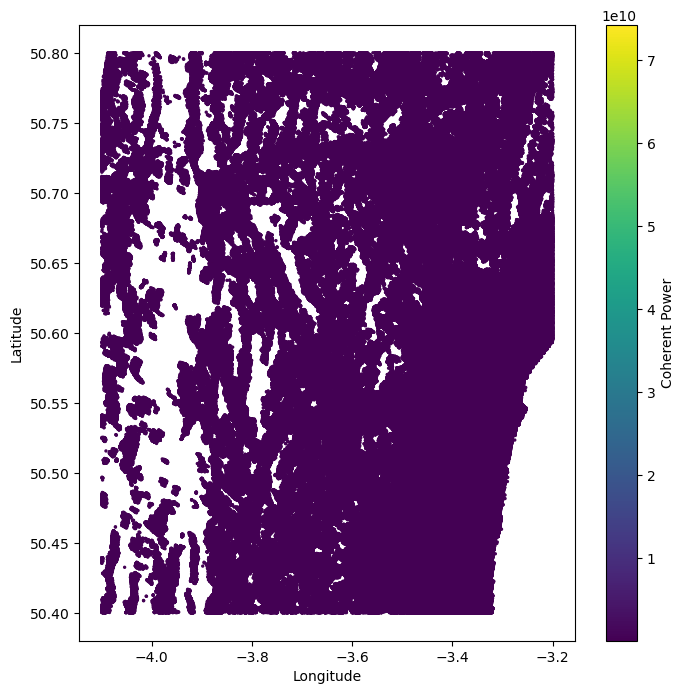

In [42]:
# plot of 'coherent power'

lon_min = -4.1
lon_max = -3.2
lat_min = 50.4
lat_max = 50.8

mask = (
    (data.longitude >= lon_min) &
    (data.longitude <= lon_max) &
    (data.latitude >= lat_min) &
    (data.latitude <= lat_max)
)

plt.figure(figsize=(8,8))
plt.scatter(
    data.longitude.values[mask],
    data.latitude.values[mask],
    c=data.coherent_power.values[mask],
    s=2,
    cmap="viridis"
)

plt.colorbar(label="Coherent Power")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
# checking which classification values are present 

print(np.unique(data.classification.values))

[1. 2. 3. 4. 5. 6. 7.]


In [ ]:
# checking classification definitions for this specific file 

print(data.classification.attrs)

{'long_name': 'classification', 'quality_flag': 'classification_qual', 'flag_meanings': 'land land_near_water water_near_land open_water dark_water low_coh_water_near_land open_low_coh_water', 'flag_values': array([1, 2, 3, 4, 5, 6, 7], dtype=uint8), 'valid_min': np.uint8(1), 'valid_max': np.uint8(7), 'comment': 'Flags indicating water detection results.'}


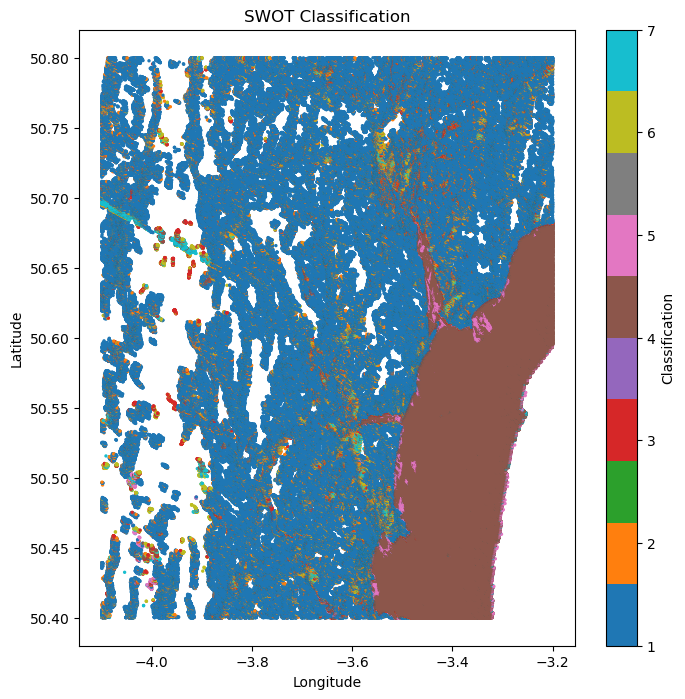

In [43]:
# plot of SWOT classification 

lon_min = -4.1
lon_max = -3.2
lat_min = 50.4
lat_max = 50.8

mask = (
    (data.longitude >= lon_min) &
    (data.longitude <= lon_max) &
    (data.latitude >= lat_min) &
    (data.latitude <= lat_max)
)

plt.figure(figsize=(8,8))
plt.scatter(
    data.longitude.values[mask],
    data.latitude.values[mask],
    c=data.classification.values[mask],
    s=2,
    cmap="tab10"
)

plt.colorbar(label="Classification")
plt.title("SWOT Classification")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

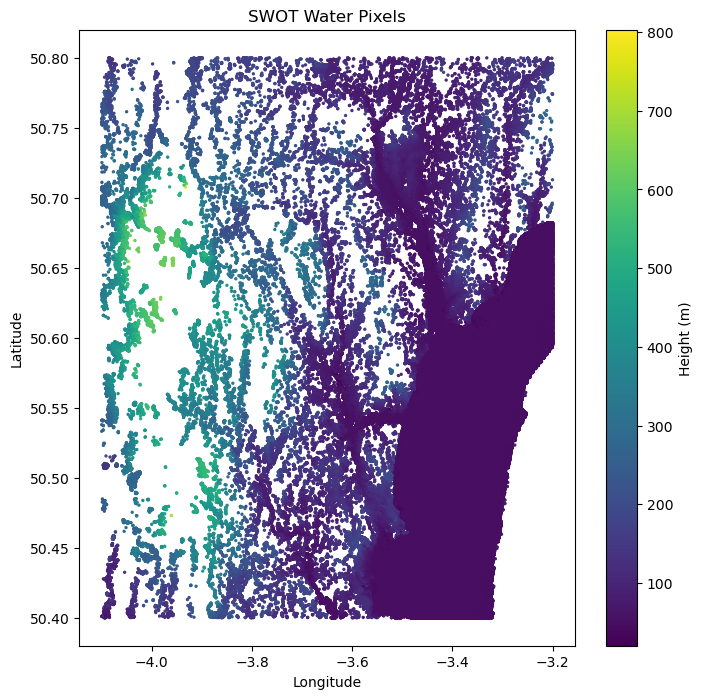

In [44]:
# filter to just water pixels and plot

lon_min = -4.1
lon_max = -3.2
lat_min = 50.4
lat_max = 50.8

subset = (
    (data.longitude >= lon_min) &
    (data.longitude <= lon_max) &
    (data.latitude >= lat_min) &
    (data.latitude <= lat_max)
)

water = np.isin(data.classification.values, [3, 4, 5, 6, 7])

mask = subset & water

plt.figure(figsize=(8,8))
plt.scatter(
    data.longitude.values[mask],
    data.latitude.values[mask],
    c=data.height.values[mask],
    s=2,
    cmap="viridis"
)

plt.colorbar(label="Height (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT Water Pixels")
plt.show()

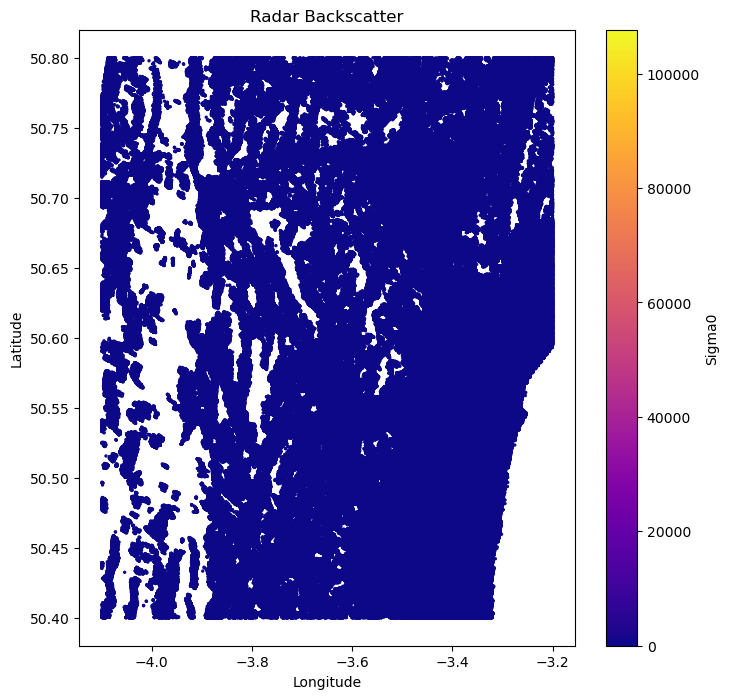

In [45]:
# plot of radar backscatter, sigma 0

lon_min = -4.1
lon_max = -3.2
lat_min = 50.4
lat_max = 50.8

mask = (
    (data.longitude >= lon_min) &
    (data.longitude <= lon_max) &
    (data.latitude >= lat_min) &
    (data.latitude <= lat_max)
)

plt.figure(figsize=(8,8))
plt.scatter(
    data.longitude.values[mask],
    data.latitude.values[mask],
    c=data.sig0.values[mask],
    s=2,
    cmap="plasma"
)

plt.colorbar(label="Sigma0")
plt.title("Radar Backscatter")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [27]:
 !pip install scipy simplekml

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65874 sha256=7554877759b56f9752d81338580d948e5983899746a265bf48508c57c7e44fe7
  Stored in directory: c:\users\pmalesza\appdata\local\pip\cache\wheels\fd\2a\d1\84a7abdbb59566c442beb1b4fb946fe1e26c5a48fd1d5e0763
Successfully built simplekml


  DEPRECATION: Building 'simplekml' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'simplekml'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [ ]:

# this creates a kml file named 'SWOT_swath_outline.kml' in the current working directory
# can open the kml file in Google Earth to view the SWOT swath outline

import numpy as np
from scipy.spatial import ConvexHull
import simplekml


lon = data.longitude.values
lat = data.latitude.values


points = np.column_stack((lon, lat))


points = points[np.isfinite(points).all(axis=1)]


hull = ConvexHull(points)
boundary = points[hull.vertices]


boundary = np.vstack([boundary, boundary[0]])


kml = simplekml.Kml()

pol = kml.newpolygon(name="SWOT PIXC Swath")
pol.outerboundaryis = [(x, y) for x, y in boundary]


pol.style.linestyle.width = 3
pol.style.polystyle.fill = 0  # transparent fill


kml.save("SWOT_swath_outline.kml")

print("Saved SWOT_swath_outline.kml")

Saved SWOT_swath_outline.kml
